# Lecture 08f: Auto-EDA Tools

Writing EDA code manually (as in notebook 08e) teaches you the fundamentals.
But in practice, **auto-EDA tools** can generate comprehensive reports with
just one or two lines of code.

In this notebook we demonstrate three popular auto-EDA libraries:

| Tool | What it does | Output |
|---|---|---|
| **Sweetviz** | Beautiful comparison reports (e.g., train vs test, or target analysis) | Self-contained HTML file |
| **PyGWalker** | Tableau-like drag-and-drop exploration directly in Jupyter | Interactive UI widget |
| **Vizro** | Low-code dashboards from DataFrames (by McKinsey) | Interactive dashboard |

We use the **Heart Disease dataset** throughout, so you can compare the auto-generated
insights with the manual EDA from notebook 08e.

### Install the tools
Run this in your terminal (with your virtual environment activated):
```bash
python -m pip install sweetviz pygwalker vizro anywidget
```

In [1]:
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Load the heart disease dataset — same as in notebook 08e.
df = pd.read_csv("predict_heart_disease_train.csv")
df = df.drop(columns=["id"])  # Drop the row identifier
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 630,000 rows × 14 columns


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


---
## 1. Sweetviz

[Documentation](https://github.com/fbdesignpro/sweetviz)  

Sweetviz creates high-density visualizations in a single HTML file.
Its killer feature: **target analysis** — it automatically shows how every
feature relates to the target variable.

It can also **compare** two datasets side-by-side (e.g., train vs test).

In [5]:
import sweetviz as sv

# analyze() takes the DataFrame and optionally a target feature.
# Specifying the target adds target-specific analysis to every feature.
# Note: Sweetviz requires the target to be numeric or boolean.
# "Heart Disease" is categorical ("Presence"/"Absence"), so we map it to 1/0.
df_sv = df.copy()
df_sv["Heart Disease"] = df_sv["Heart Disease"].map({"Presence": 1, "Absence": 0})

report = sv.analyze(
    df_sv,
    target_feat="Heart Disease",
)

# show_html() opens the report in your browser.
# show_notebook() displays it inline (but can be large).
report.show_html("heart_disease_sweetviz.html", open_browser=False)
print("Sweetviz report saved to heart_disease_sweetviz.html")

                                             |          | [  0%]   00:00 -> (? left)

Report heart_disease_sweetviz.html was generated.
Sweetviz report saved to heart_disease_sweetviz.html



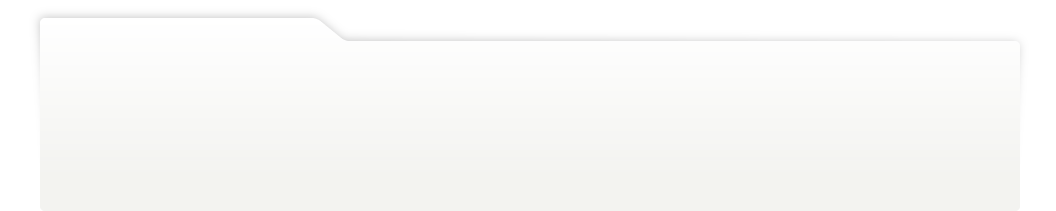
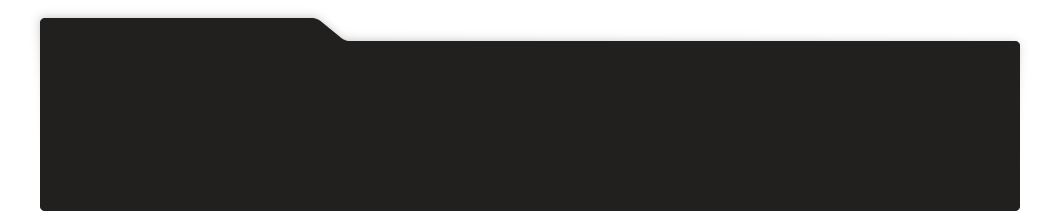
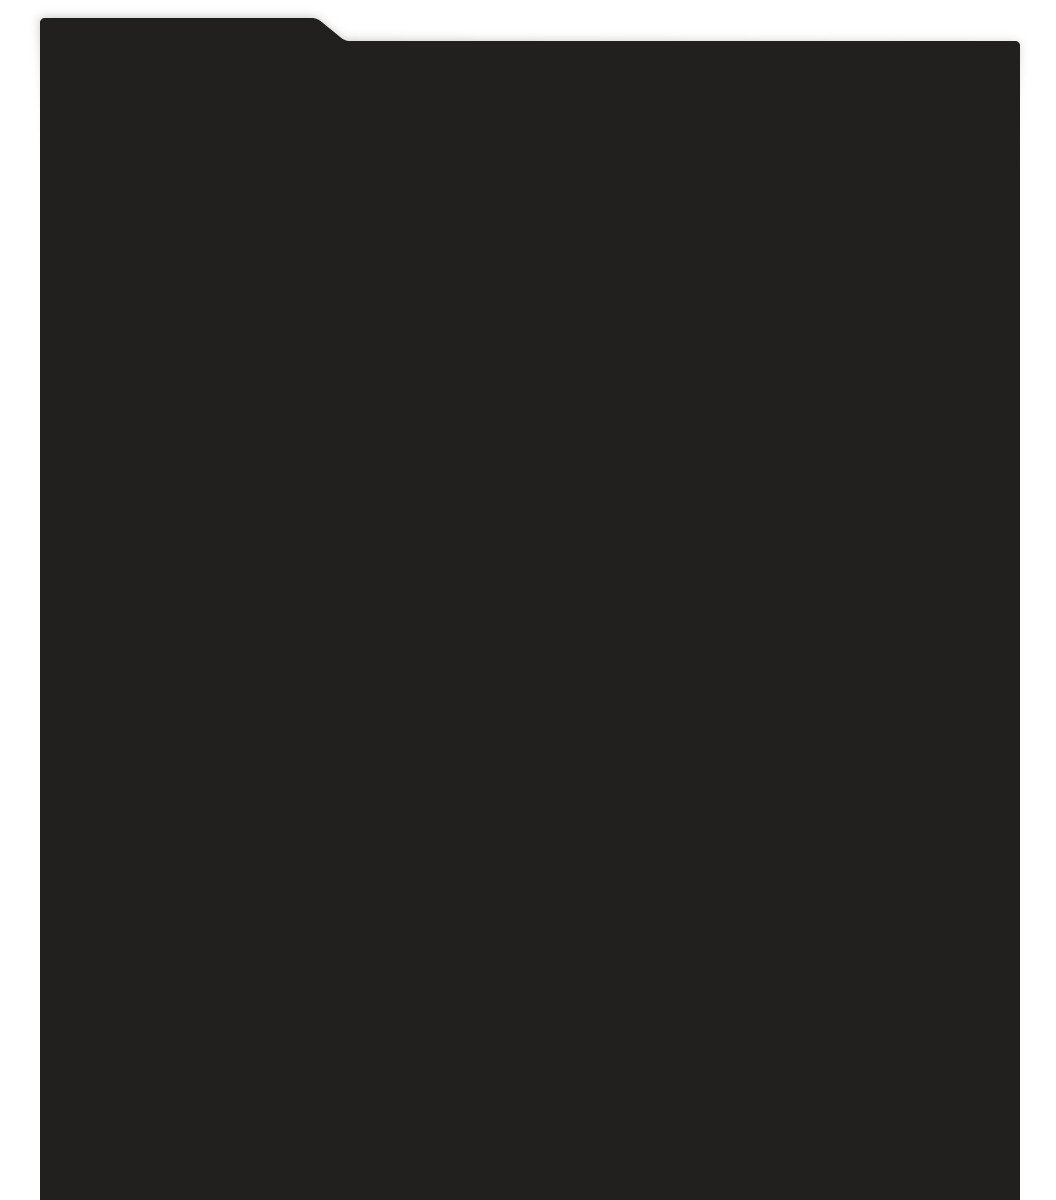
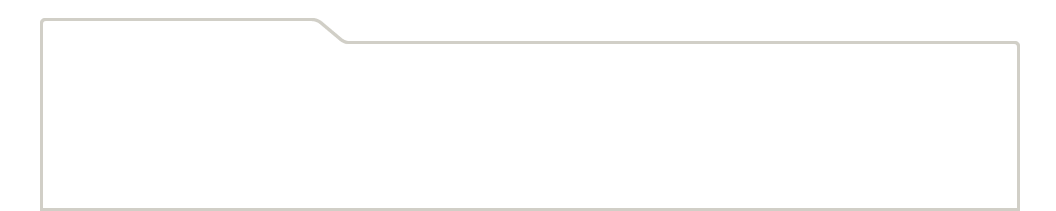
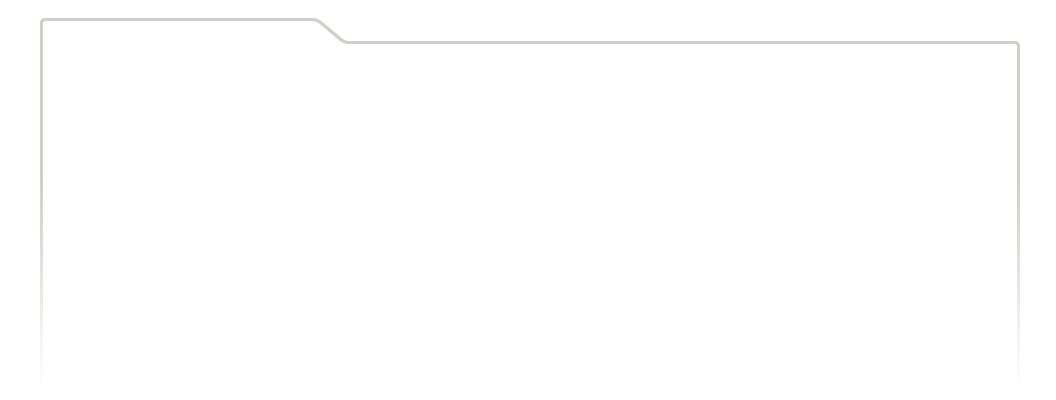
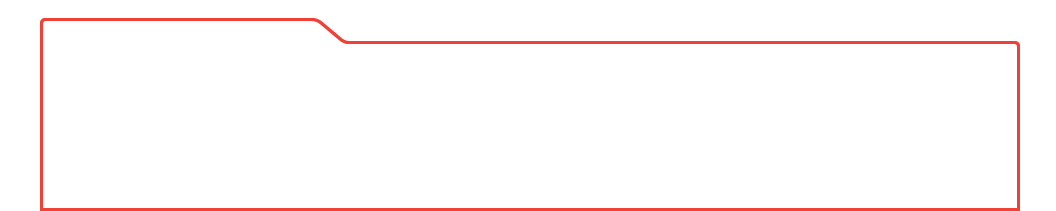
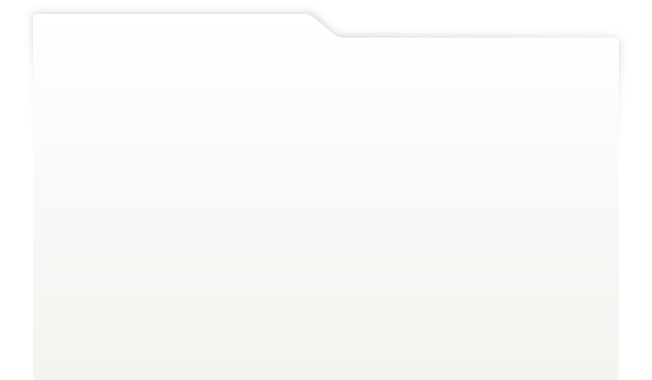
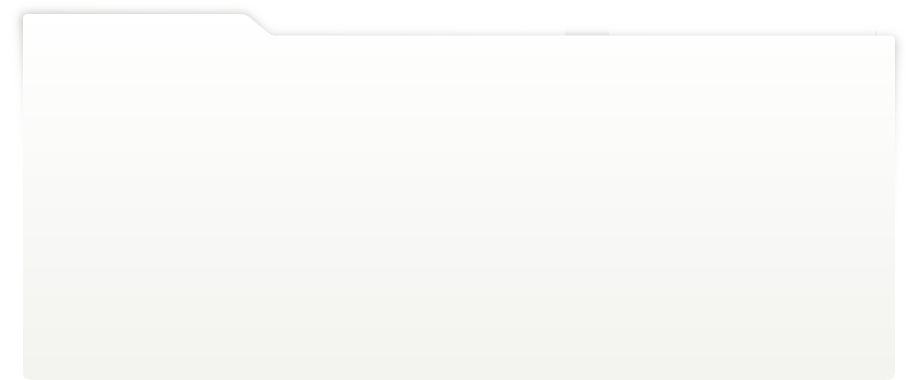
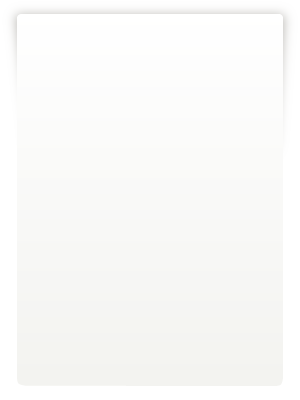
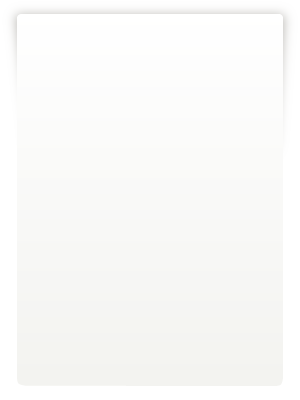
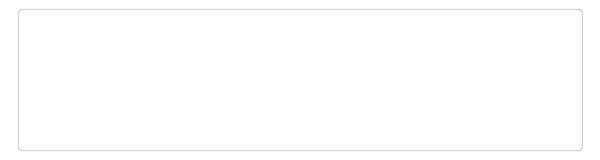
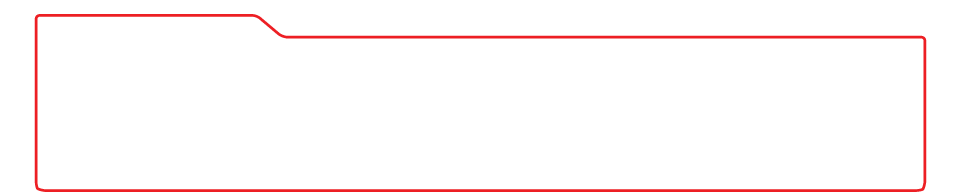
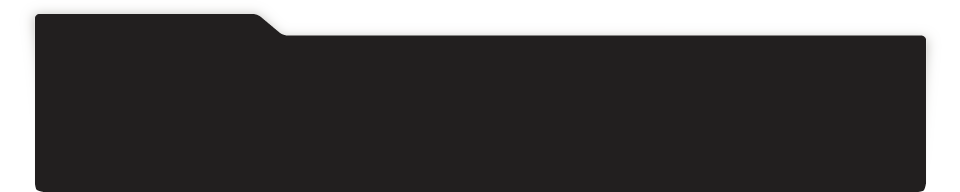
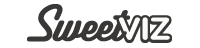
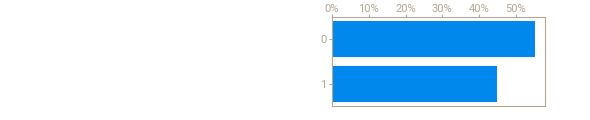
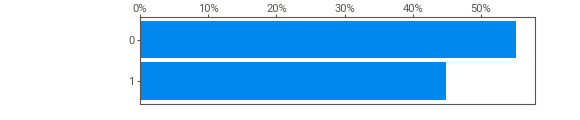
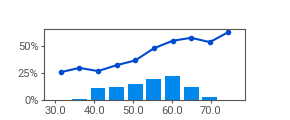
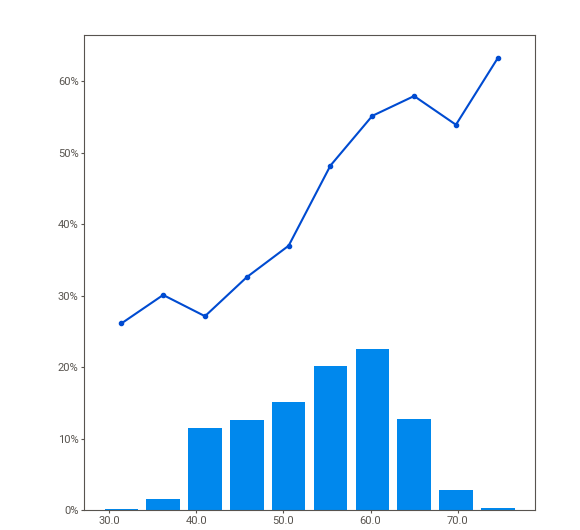
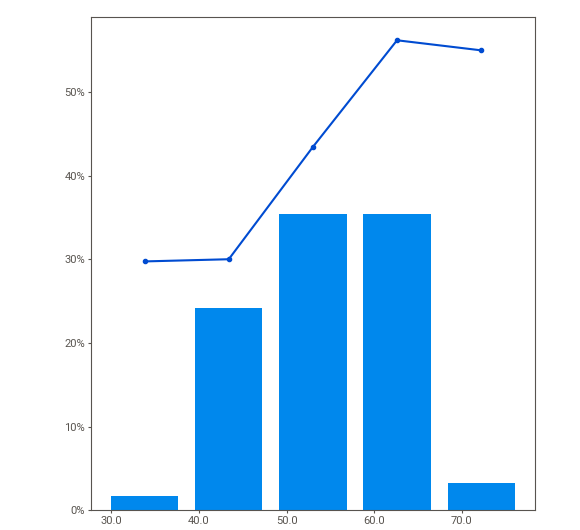
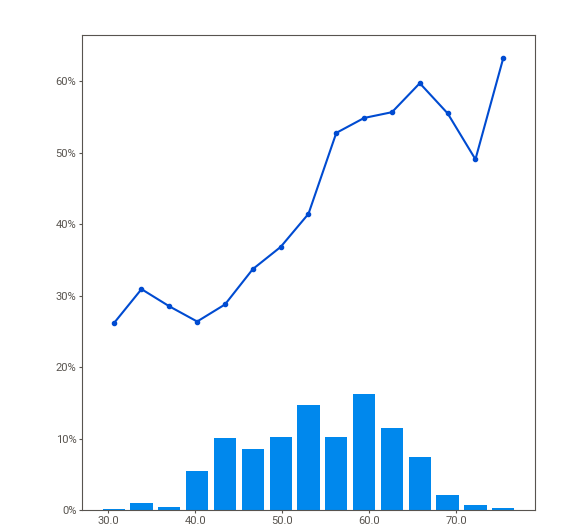
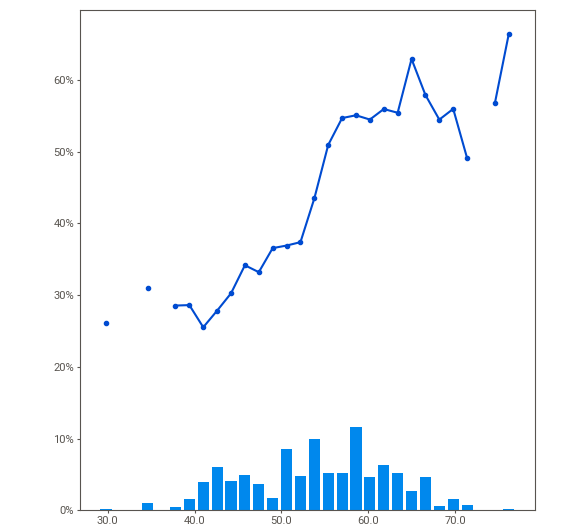
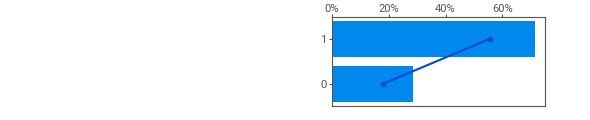
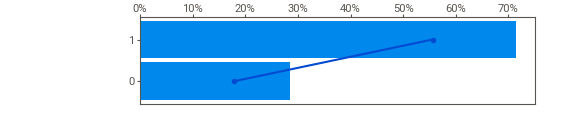
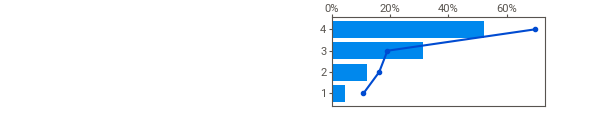
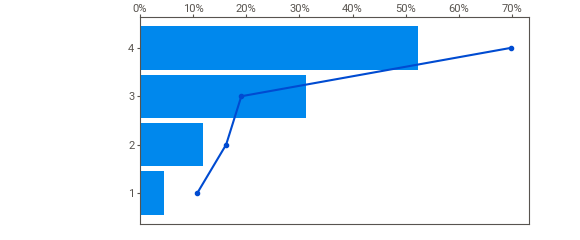
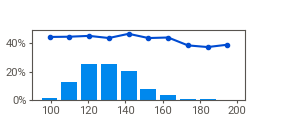
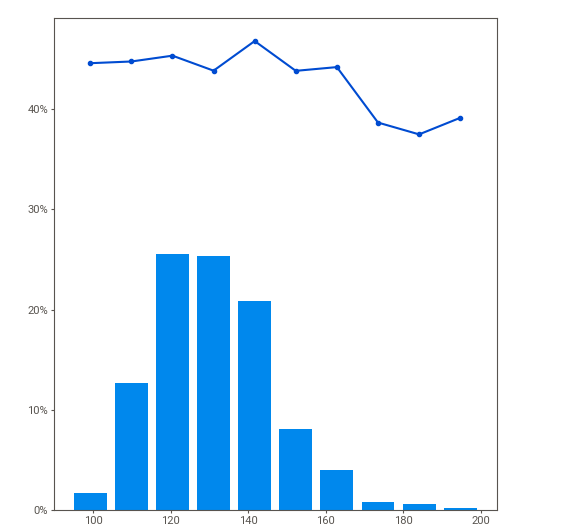
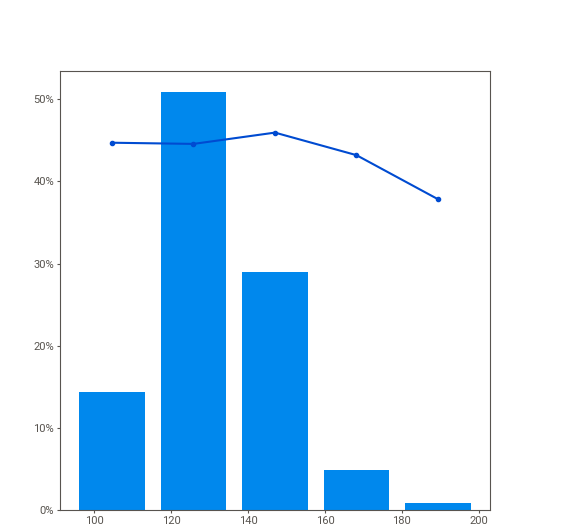
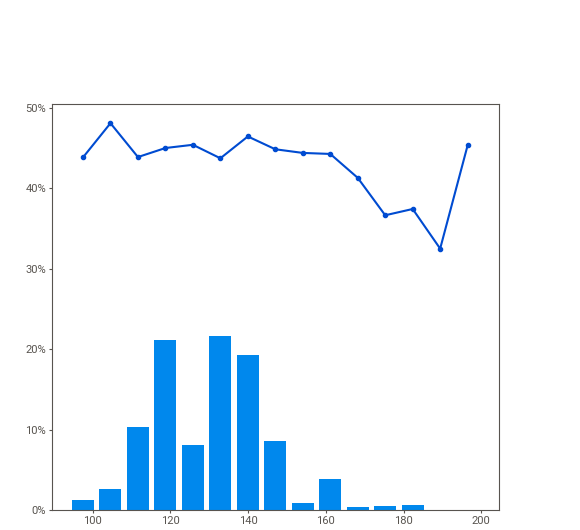
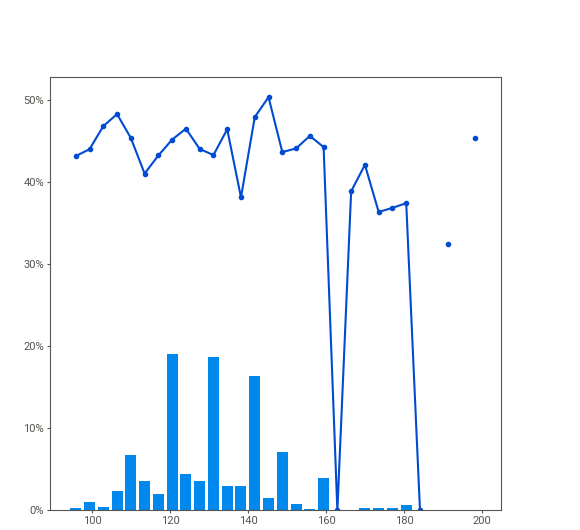
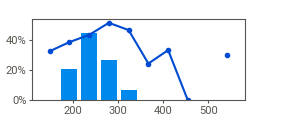
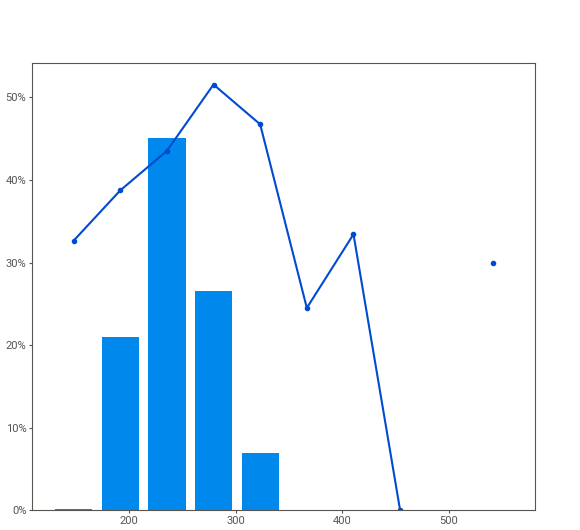
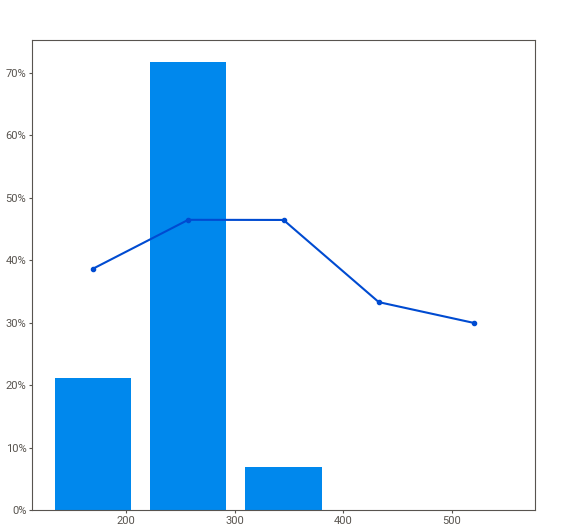
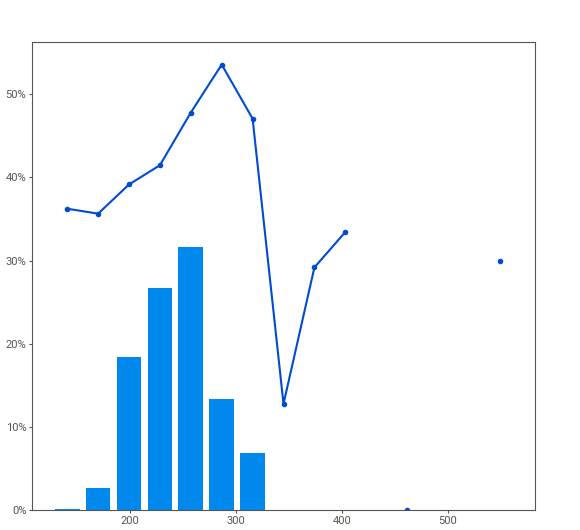
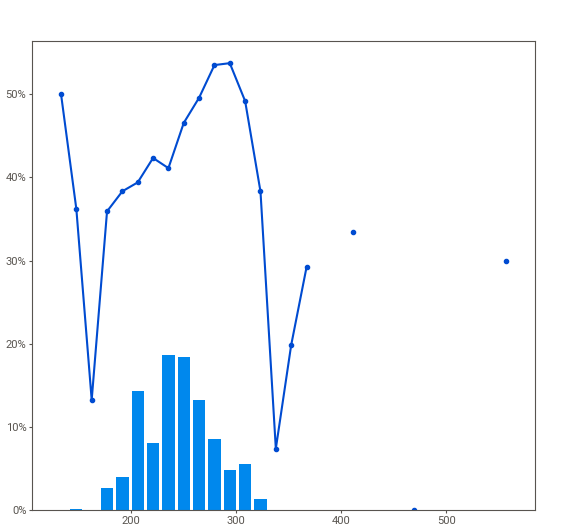
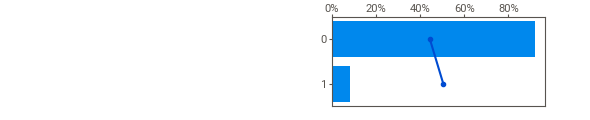
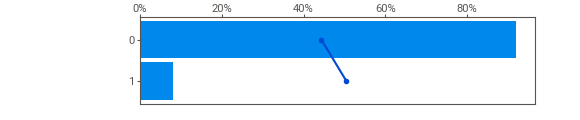
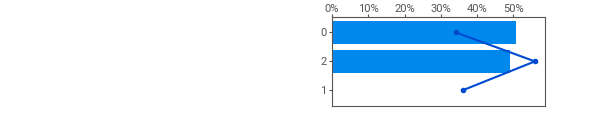
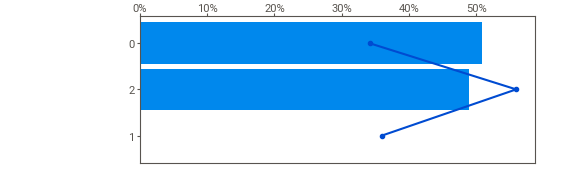
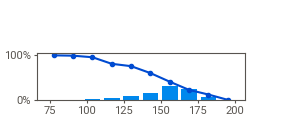
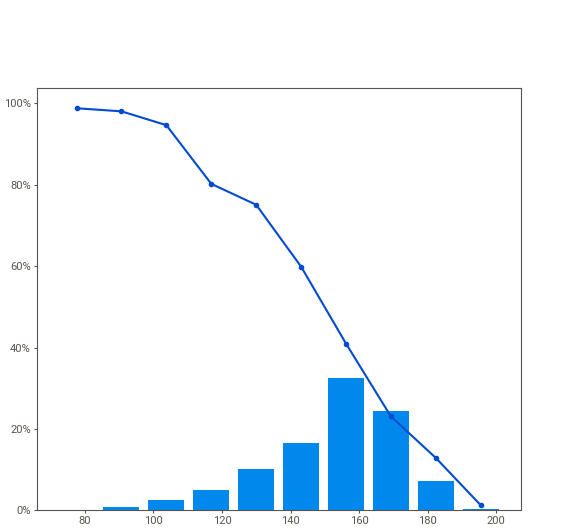
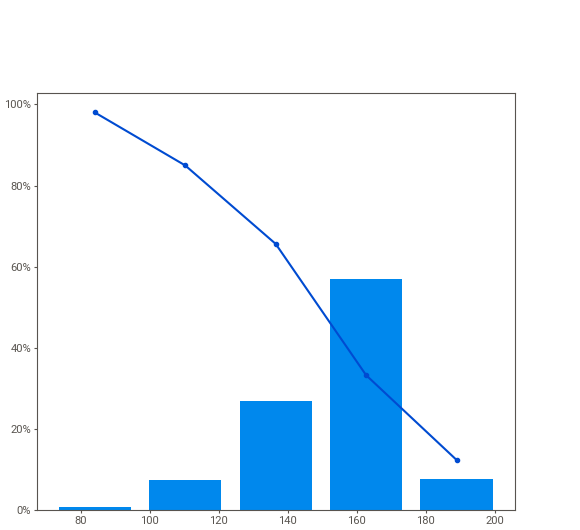
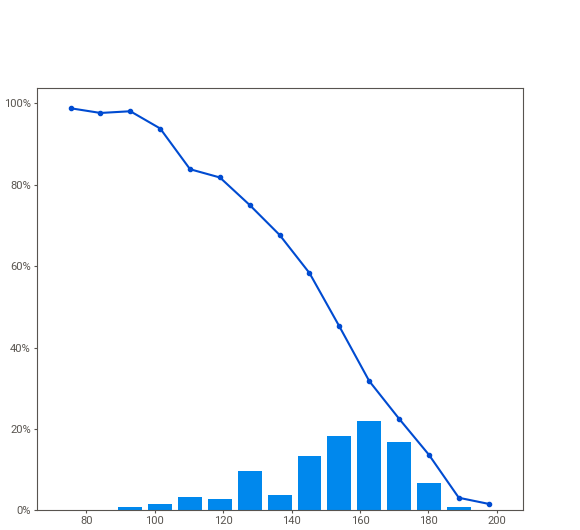
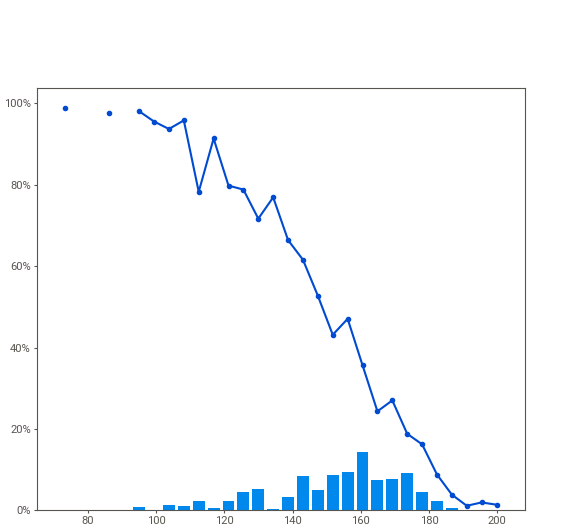
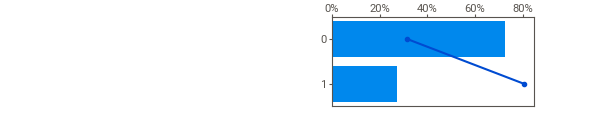
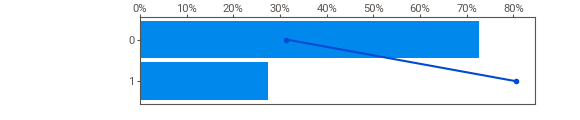
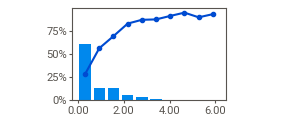
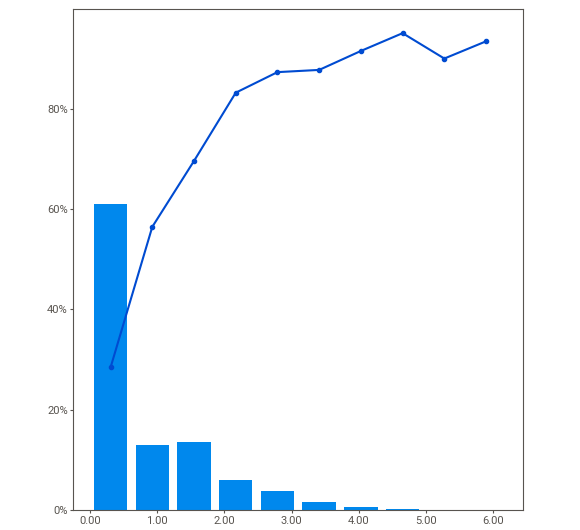
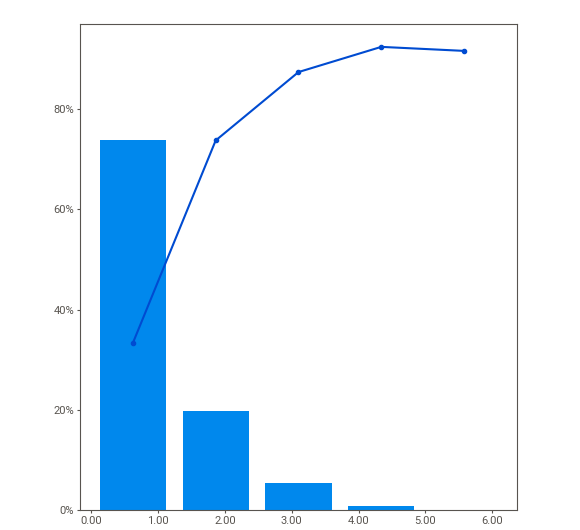
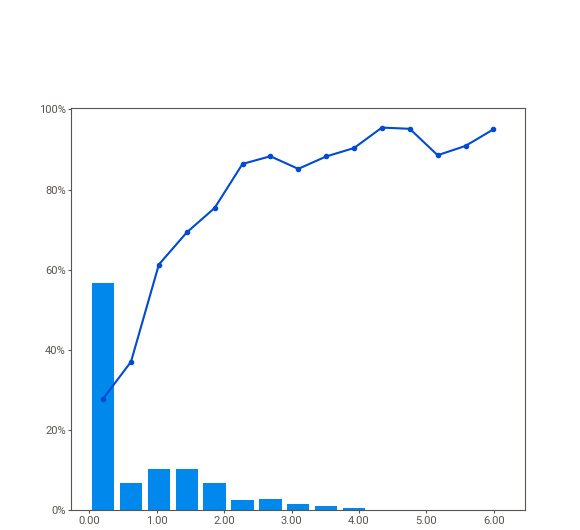
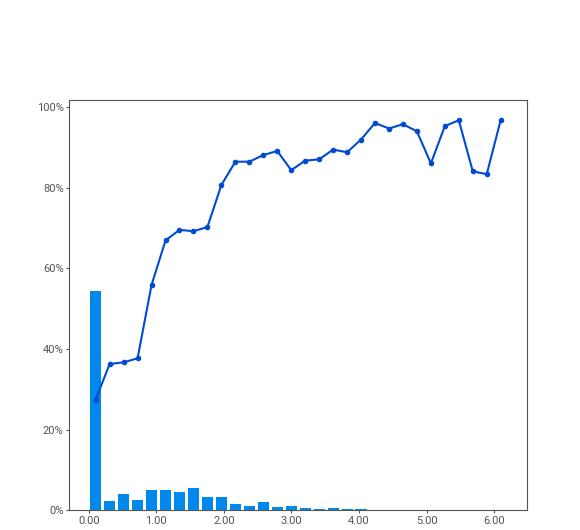
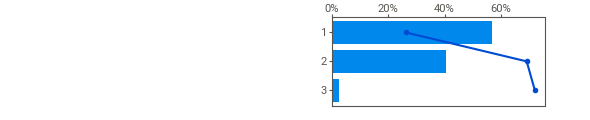
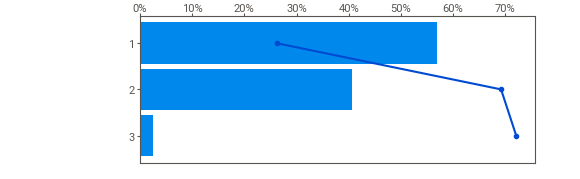
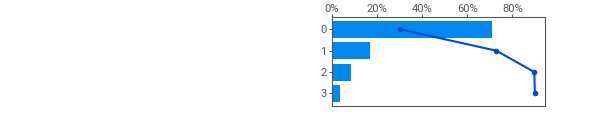
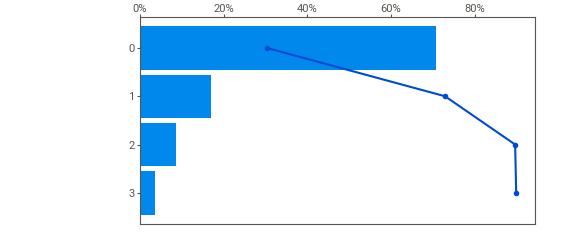
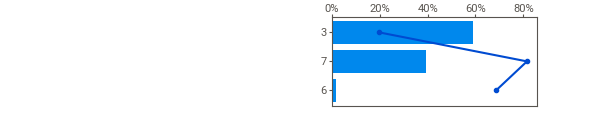
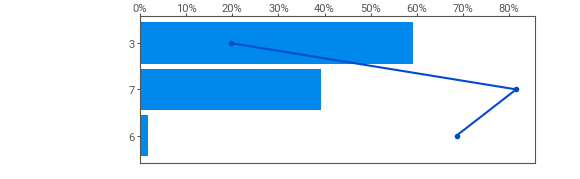
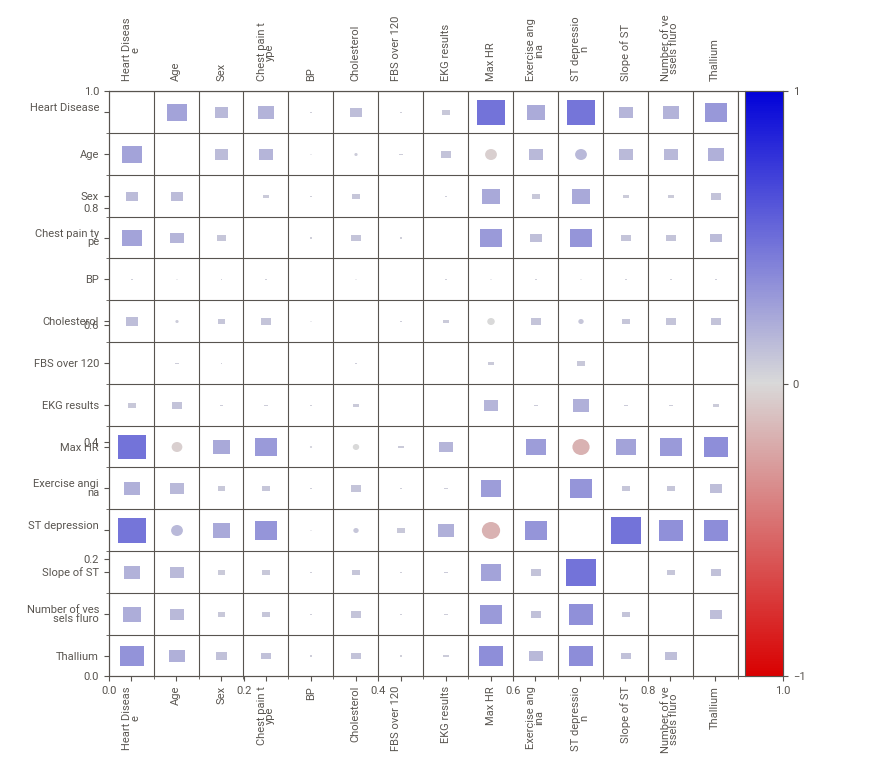
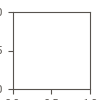

In [6]:
# Display the Sweetviz report inline in the notebook.
# Note: this embeds a large HTML report inside the notebook output.
report.show_notebook()

In [7]:
# BONUS: Sweetviz can compare two datasets side-by-side.
# This is useful for comparing train vs test splits.
# Example (uncomment to try):

# from sklearn.model_selection import train_test_split
# train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# comparison = sv.compare([train_df, "Train"], [test_df, "Test"], target_feat="Heart Disease")
# comparison.show_html("heart_disease_sweetviz_comparison.html")

---
## 2. PyGWalker — Drag-and-Drop Exploration

[Documentation](https://github.com/Kanaries/pygwalker)  

PyGWalker turns your DataFrame into an interactive **Tableau-like** interface
directly inside Jupyter. You can:
- Drag fields to x-axis, y-axis, color, size
- Switch chart types with one click
- Create filters and groupings visually
- Export charts

This is extremely useful for **quick, ad-hoc exploration** when you don't
want to write code for every plot.

In [11]:
import pygwalker as pyg

# walk() creates an interactive widget where you can drag and drop columns
# to create different visualizations — no code needed!
# Try dragging "Age" to the x-axis, "Max HR" to the y-axis,
# and "Heart Disease" to the color shelf.
#
# env="Jupyter" renders as an HTML iframe — more compatible with VS Code notebooks.
# The default "JupyterWidget" mode can show raw HTML in some editors.
walker = pyg.walk(df, env="Jupyter")

---
## 3. Vizro — Low-Code Dashboards by McKinsey

[Documentation](https://vizro.readthedocs.io/)  
[GitHub](https://github.com/mckinsey/vizro)

Vizro is a framework for creating **modular data visualization dashboards**
with minimal code. Built on top of Plotly and Dash, it lets you define
dashboards using simple Python configuration — no frontend code needed.

Key features:
- Declarative dashboard definition (Python dicts or Pydantic models)
- Built-in chart types powered by Plotly
- Interactive filters, parameters, and selectors out of the box
- Themeable and responsive layouts
- Can be served as a web app or explored in a notebook

### Install
```bash
python -m pip install vizro
```

In [12]:
import vizro.plotly.express as vpx
from vizro import Vizro
import vizro.models as vm

# Define a simple dashboard with a scatter plot and a histogram.
# Vizro uses a declarative model: you describe WHAT you want, not HOW to render it.

page = vm.Page(
    title="Heart Disease Explorer",
    components=[
        vm.Graph(
            figure=vpx.scatter(
                df,
                x="Age",
                y="Max HR",
                color="Heart Disease",
                title="Age vs Max Heart Rate"
            )
        ),
        vm.Graph(
            figure=vpx.
histogram(
                df,
                x="Cholesterol",
                color="Heart Disease",
                title="Cholesterol Distribution"
            )
        ),
    ],
    controls=[
        vm.Filter(column="Heart Disease"),
        vm.Filter(column="Sex"),
    ],
)

dashboard = vm.Dashboard(pages=[page])

# In a notebook, use Vizro().build(dashboard).run() to serve, or:
Vizro().build(dashboard).run(port=8050)

---
## 4. Comparison & When to Use What

| Scenario | Recommended Tool |
|---|---|
| Compare train vs test data distributions | **Sweetviz** |
| Target-focused analysis | **Sweetviz** |
| Ad-hoc interactive exploration | **PyGWalker** |
| Low-code dashboards from DataFrames | **Vizro** |
| Custom, publication-ready plots | Manual code (plotly, seaborn, matplotlib) |

### Key insight
Auto-EDA tools are **starting points**, not replacements for manual analysis.
They're great for the first pass, but you'll always need custom plots
for specific hypotheses and presentations.

### Practice Exercises
1. Use Sweetviz `compare()` to compare male vs female patients.
2. In PyGWalker, create a scatter plot of Age vs Max HR colored by Heart Disease. Then switch to a bar chart.
3. Try Vizro: add a filter for "Heart Disease" and a second chart (e.g., box plot of Cholesterol by Heart Disease).
4. Try using one of these tools on a completely different dataset (e.g., the iris dataset from notebook 08d).